In [4]:
import fastf1
fastf1.Cache.enable_cache('cache')

session = fastf1.get_session(2026, 'Monza', 'Q')
session.load()

ModuleNotFoundError: No module named 'fastf1'

In [ ]:
!pip install fastf1 numpy scipy pandas matplotlib

In [ ]:
import fastf1
fastf1.Cache.enable_cache('cache')

session = fastf1.get_session(2026, 'Monza', 'Q')
session.load()

In [ ]:
import sys
print(sys.executable)

In [ ]:
import sys
!{sys.executable} -m pip install fastf1 numpy scipy pandas matplotlib

In [ ]:
import fastf1
fastf1.Cache.enable_cache('cache')

session = fastf1.get_session(2026, 'Monza', 'Q')
session.load()

In [ ]:
import os
os.makedirs('cache', exist_ok=True)

import fastf1
fastf1.Cache.enable_cache('cache')

session = fastf1.get_session(2026, 'Monza', 'Q')
session.load()

In [5]:
import os
os.makedirs('cache', exist_ok=True)

import fastf1
fastf1.Cache.enable_cache('cache')

session = fastf1.get_session(2026, 'Dutch', 'Q')
session.load()

ModuleNotFoundError: No module named 'fastf1'

In [ ]:
lap = session.pick_fastest()
telemetry = lap.get_telemetry()
telemetry.head()

In [ ]:
lap = session.laps.pick_fastest()
telemetry = lap.get_telemetry()
telemetry.head()

In [ ]:
import numpy as np

x = telemetry['X'].values
y = telemetry['Y'].values

dx = np.gradient(x)
dy = np.gradient(y)
ddx = np.gradient(dx)
ddy = np.gradient(dy)

curvature = np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2)**1.5
radius = 1 / np.maximum(curvature, 1e-6)

In [ ]:
import matplotlib.pyplot as plt
plt.plot(telemetry['X'], telemetry['Y'])
plt.axis('equal')
plt.show()

In [ ]:
plt.plot(telemetry['Distance'], radius)
plt.ylim(0, 1000)  # zoom in, since straights can spike to huge values
plt.xlabel('Distance (m)')
plt.ylabel('Radius of curvature (m)')
plt.show()

In [6]:
from scipy.signal import savgol_filter

x_smooth = savgol_filter(x, window_length=21, polyorder=3)
y_smooth = savgol_filter(y, window_length=21, polyorder=3)

dx = np.gradient(x_smooth)
dy = np.gradient(y_smooth)
ddx = np.gradient(dx)
ddy = np.gradient(dy)

curvature = np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2)**1.5
radius = 1 / np.maximum(curvature, 1e-6)

NameError: name 'x' is not defined

In [ ]:
plt.plot(telemetry['Distance'], radius)
plt.ylim(0, 1000)  # zoom in, since straights can spike to huge values
plt.xlabel('Distance (m)')
plt.ylabel('Radius of curvature (m)')
plt.show()

In [ ]:
x_smooth = savgol_filter(x, window_length=41, polyorder=3)
y_smooth = savgol_filter(y, window_length=41, polyorder=3)

dx = np.gradient(x_smooth)
dy = np.gradient(y_smooth)
ddx = np.gradient(dx)
ddy = np.gradient(dy)

curvature = np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2)**1.5
radius = 1 / np.maximum(curvature, 1e-6)

In [ ]:
plt.plot(telemetry['Distance'], radius)
plt.ylim(0, 1000)  # zoom in, since straights can spike to huge values
plt.xlabel('Distance (m)')
plt.ylabel('Radius of curvature (m)')
plt.show()

In [ ]:
from scipy.signal import find_peaks

# corners are local minima of radius = local maxima of -radius
inv_radius = -radius
peaks, properties = find_peaks(inv_radius, prominence=100, distance=20)

print(f"Number of corners detected: {len(peaks)}")
print(telemetry['Distance'].values[peaks])

In [ ]:
peaks, properties = find_peaks(inv_radius, prominence=200, distance=30)
print(f"Number of corners detected: {len(peaks)}")

In [ ]:
plt.plot(telemetry['Distance'], radius)
plt.plot(telemetry['Distance'].values[peaks], radius[peaks], 'rx', markersize=10)
plt.ylim(0, 1000)
plt.xlabel('Distance (m)')
plt.ylabel('Radius of curvature (m)')
plt.show()

In [ ]:
plt.plot(telemetry['Distance'], radius)
plt.plot(telemetry['Distance'].values[peaks], radius[peaks], 'rx', markersize=10)
plt.ylim(0, 3000)  # raised so no markers get clipped
plt.xlabel('Distance (m)')
plt.ylabel('Radius of curvature (m)')
plt.show()

In [ ]:
for d, r in zip(telemetry['Distance'].values[peaks], radius[peaks]):
    print(f"Distance: {d:.0f} m, Radius: {r:.0f} m")

In [ ]:
valid = radius[peaks] < 10000  # drop unrealistic straight-line artifacts
corner_distances = telemetry['Distance'].values[peaks][valid]
corner_radii = radius[peaks][valid]

print(f"Number of real corners: {len(corner_radii)}")
for d, r in zip(corner_distances, corner_radii):
    print(f"Distance: {d:.0f} m, Radius: {r:.0f} m")

In [ ]:
m = 768        # kg, car + driver, per 2026 regs
mu = 1.6       # effective tyre-road friction coefficient (approx, informed estimate)
rho = 1.225    # air density, kg/m^3
A = 1.5        # frontal area, m^2 (approx)
g = 9.81

# Two aero states
Cl_Z, Cd_Z = 3.0, 1.0   # Z-mode: high downforce, high drag (corner mode)
Cl_X, Cd_X = 1.8, 0.55  # X-mode: low downforce, low drag (straight mode)

def downforce(v, mode):
    Cl = Cl_X if mode == 'X' else Cl_Z
    return 0.5 * rho * Cl * A * v**2

def drag(v, mode):
    Cd = Cd_X if mode == 'X' else Cd_Z
    return 0.5 * rho * Cd * A * v**2

def aero_mode(radius_i, speed_threshold_radius=300):
    return 'X' if radius_i > speed_threshold_radius else 'Z'

In [ ]:
from scipy.optimize import brentq

def max_corner_speed(radius_i, mode):
    def equation(v):
        F_down = downforce(v, mode)
        return mu * (m * g + F_down) / m - v**2 / radius_i
    return brentq(equation, 1, 150)

v_corner = np.array([
    max_corner_speed(r, aero_mode(r)) for r in radius
])

In [7]:
def max_corner_speed(radius_i, mode):
    def equation(v):
        F_down = downforce(v, mode)
        return mu * (m * g + F_down) / m - v**2 / radius_i

    if equation(150) > 0:
        # even at 150 m/s, grip isn't the limiting factor — essentially a straight
        return 150.0
    return brentq(equation, 1, 150)

v_corner = np.array([
    max_corner_speed(r, aero_mode(r)) for r in radius
])

NameError: name 'radius' is not defined

In [ ]:
plt.plot(telemetry['Distance'], v_corner)
plt.xlabel('Distance (m)')
plt.ylabel('Max cornering speed (m/s)')
plt.show()

In [ ]:
mu = 1.2  # more realistic standalone tyre friction coefficient/

In [ ]:
def max_corner_speed(radius_i, mode):
    def equation(v):
        F_down = downforce(v, mode)
        return mu * (m * g + F_down) / m - v**2 / radius_i

    if equation(150) > 0:
        # even at 150 m/s, grip isn't the limiting factor — essentially a straight
        return 150.0
    return brentq(equation, 1, 150)

v_corner = np.array([
    max_corner_speed(r, aero_mode(r)) for r in radius
])

In [ ]:
plt.plot(telemetry['Distance'], v_corner)
plt.xlabel('Distance (m)')
plt.ylabel('Max cornering speed (m/s)')
plt.show()

In [ ]:
mu = 0.9

In [ ]:
def max_corner_speed(radius_i, mode):
    def equation(v):
        F_down = downforce(v, mode)
        return mu * (m * g + F_down) / m - v**2 / radius_i

    if equation(150) > 0:
        # even at 150 m/s, grip isn't the limiting factor — essentially a straight
        return 150.0
    return brentq(equation, 1, 150)

v_corner = np.array([
    max_corner_speed(r, aero_mode(r)) for r in radius
])

In [ ]:
plt.plot(telemetry['Distance'], v_corner)
plt.xlabel('Distance (m)')
plt.ylabel('Max cornering speed (m/s)')
plt.show()

In [ ]:
ds = np.gradient(telemetry['Distance'].values)
v_fwd = np.zeros_like(v_corner)
v_fwd[0] = v_corner[0]

P_max = 800_000  # W, approx power limit (2026 regs ~800kW total)

for i in range(1, len(v_fwd)):
    mode = aero_mode(radius[i])
    v_prev = v_fwd[i-1]
    F_drag = drag(v_prev, mode)
    F_trac_limit = mu * (m * g + downforce(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds[i], 0))
    v_fwd[i] = min(v_new, v_corner[i])

In [ ]:
plt.plot(telemetry['Distance'], v_fwd)
plt.xlabel('Distance (m)')
plt.ylabel('Forward-pass speed (m/s)')
plt.show()

In [8]:
v_bwd = np.zeros_like(v_corner)
v_bwd[-1] = v_corner[-1]
a_brake_max = 5.0 * g  # approx max braking deceleration, m/s^2

for i in range(len(v_bwd)-2, -1, -1):
    v_next = v_bwd[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds[i+1], 0))
    v_bwd[i] = min(v_new, v_corner[i])

NameError: name 'v_corner' is not defined

In [ ]:
plt.plot(telemetry['Distance'], v_bwd)
plt.xlabel('Distance (m)')
plt.ylabel('Backward-pass speed (m/s)')
plt.show()

In [ ]:
v_final = np.minimum(np.minimum(v_fwd, v_bwd), v_corner)

plt.plot(telemetry['Distance'], v_final, label='Simulated')
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.legend()
plt.show()

In [ ]:
lap_time_sim = np.sum(ds[1:] / v_final[1:])
print(f"Simulated lap time: {lap_time_sim:.2f} s")

In [ ]:
plt.plot(telemetry['Distance'], v_final, label='Simulated')
plt.plot(telemetry['Distance'], telemetry['Speed']/3.6, label='Real (telemetry)')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.show()

In [ ]:
mu = 0.65        # lower grip — brings corner speeds down
Cd_X = 0.9        # more drag in X-mode — brings top speed down (was 0.55)

In [ ]:
v_corner = np.array([
    max_corner_speed(r, aero_mode(r)) for r in radius
])

v_fwd = np.zeros_like(v_corner)
v_fwd[0] = v_corner[0]
for i in range(1, len(v_fwd)):
    mode = aero_mode(radius[i])
    v_prev = v_fwd[i-1]
    F_drag = drag(v_prev, mode)
    F_trac_limit = mu * (m * g + downforce(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds[i], 0))
    v_fwd[i] = min(v_new, v_corner[i])

v_bwd = np.zeros_like(v_corner)
v_bwd[-1] = v_corner[-1]
for i in range(len(v_bwd)-2, -1, -1):
    v_next = v_bwd[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds[i+1], 0))
    v_bwd[i] = min(v_new, v_corner[i])

v_final = np.minimum(np.minimum(v_fwd, v_bwd), v_corner)

lap_time_sim = np.sum(ds[1:] / v_final[1:])
print(f"Simulated lap time: {lap_time_sim:.2f} s")

plt.plot(telemetry['Distance'], v_final, label='Simulated')
plt.plot(telemetry['Distance'], telemetry['Speed']/3.6, label='Real (telemetry)')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.show()

In [ ]:
mu = 0.45         # lower still — corners still ~25-30% too fast
Cd_X = 1.3         # more drag — straights still ~15% too fast

In [ ]:
v_corner = np.array([
    max_corner_speed(r, aero_mode(r)) for r in radius
])

v_fwd = np.zeros_like(v_corner)
v_fwd[0] = v_corner[0]
for i in range(1, len(v_fwd)):
    mode = aero_mode(radius[i])
    v_prev = v_fwd[i-1]
    F_drag = drag(v_prev, mode)
    F_trac_limit = mu * (m * g + downforce(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds[i], 0))
    v_fwd[i] = min(v_new, v_corner[i])

v_bwd = np.zeros_like(v_corner)
v_bwd[-1] = v_corner[-1]
for i in range(len(v_bwd)-2, -1, -1):
    v_next = v_bwd[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds[i+1], 0))
    v_bwd[i] = min(v_new, v_corner[i])

v_final = np.minimum(np.minimum(v_fwd, v_bwd), v_corner)

lap_time_sim = np.sum(ds[1:] / v_final[1:])
print(f"Simulated lap time: {lap_time_sim:.2f} s")

plt.plot(telemetry['Distance'], v_final, label='Simulated')
plt.plot(telemetry['Distance'], telemetry['Speed']/3.6, label='Real (telemetry)')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.show()

In [ ]:
print(lap['LapTime'])

In [ ]:
real_time_seconds = lap['LapTime'].total_seconds()
gap = lap_time_sim - real_time_seconds
print(f"Real lap time: {real_time_seconds:.2f} s")
print(f"Simulated lap time: {lap_time_sim:.2f} s")
print(f"Gap: {gap:+.2f} s")

In [ ]:
def aero_mode_fixed(radius_i):
    return 'Z'  # always high-downforce, no active switching — pre-2026 style

In [ ]:
v_corner_fixed = np.array([
    max_corner_speed(r, aero_mode_fixed(r)) for r in radius
])

v_fwd_fixed = np.zeros_like(v_corner_fixed)
v_fwd_fixed[0] = v_corner_fixed[0]
for i in range(1, len(v_fwd_fixed)):
    mode = aero_mode_fixed(radius[i])
    v_prev = v_fwd_fixed[i-1]
    F_drag = drag(v_prev, mode)
    F_trac_limit = mu * (m * g + downforce(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds[i], 0))
    v_fwd_fixed[i] = min(v_new, v_corner_fixed[i])

v_bwd_fixed = np.zeros_like(v_corner_fixed)
v_bwd_fixed[-1] = v_corner_fixed[-1]
for i in range(len(v_bwd_fixed)-2, -1, -1):
    v_next = v_bwd_fixed[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds[i+1], 0))
    v_bwd_fixed[i] = min(v_new, v_corner_fixed[i])

v_final_fixed = np.minimum(np.minimum(v_fwd_fixed, v_bwd_fixed), v_corner_fixed)

lap_time_fixed = np.sum(ds[1:] / v_final_fixed[1:])

print(f"Active aero lap time:  {lap_time_sim:.2f} s")
print(f"Fixed aero lap time:   {lap_time_fixed:.2f} s")
print(f"Active aero saving:    {lap_time_fixed - lap_time_sim:.2f} s")

In [9]:
def aero_mode(radius_i, speed_threshold_radius=2000):
    return 'X' if radius_i > speed_threshold_radius else 'Z'

In [10]:
v_corner_fixed = np.array([
    max_corner_speed(r, aero_mode_fixed(r)) for r in radius
])

v_fwd_fixed = np.zeros_like(v_corner_fixed)
v_fwd_fixed[0] = v_corner_fixed[0]
for i in range(1, len(v_fwd_fixed)):
    mode = aero_mode_fixed(radius[i])
    v_prev = v_fwd_fixed[i-1]
    F_drag = drag(v_prev, mode)
    F_trac_limit = mu * (m * g + downforce(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds[i], 0))
    v_fwd_fixed[i] = min(v_new, v_corner_fixed[i])

v_bwd_fixed = np.zeros_like(v_corner_fixed)
v_bwd_fixed[-1] = v_corner_fixed[-1]
for i in range(len(v_bwd_fixed)-2, -1, -1):
    v_next = v_bwd_fixed[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds[i+1], 0))
    v_bwd_fixed[i] = min(v_new, v_corner_fixed[i])

v_final_fixed = np.minimum(np.minimum(v_fwd_fixed, v_bwd_fixed), v_corner_fixed)

lap_time_fixed = np.sum(ds[1:] / v_final_fixed[1:])

print(f"Active aero lap time:  {lap_time_sim:.2f} s")
print(f"Fixed aero lap time:   {lap_time_fixed:.2f} s")
print(f"Active aero saving:    {lap_time_fixed - lap_time_sim:.2f} s")

NameError: name 'radius' is not defined

In [ ]:
def aero_mode(radius_i, speed_threshold_radius=2000):
    return 'X' if radius_i > speed_threshold_radius else 'Z'

In [ ]:
v_corner_fixed = np.array([
    max_corner_speed(r, aero_mode_fixed(r)) for r in radius
])

v_fwd_fixed = np.zeros_like(v_corner_fixed)
v_fwd_fixed[0] = v_corner_fixed[0]
for i in range(1, len(v_fwd_fixed)):
    mode = aero_mode_fixed(radius[i])
    v_prev = v_fwd_fixed[i-1]
    F_drag = drag(v_prev, mode)
    F_trac_limit = mu * (m * g + downforce(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds[i], 0))
    v_fwd_fixed[i] = min(v_new, v_corner_fixed[i])

v_bwd_fixed = np.zeros_like(v_corner_fixed)
v_bwd_fixed[-1] = v_corner_fixed[-1]
for i in range(len(v_bwd_fixed)-2, -1, -1):
    v_next = v_bwd_fixed[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds[i+1], 0))
    v_bwd_fixed[i] = min(v_new, v_corner_fixed[i])

v_final_fixed = np.minimum(np.minimum(v_fwd_fixed, v_bwd_fixed), v_corner_fixed)

lap_time_fixed = np.sum(ds[1:] / v_final_fixed[1:])

print(f"Active aero lap time:  {lap_time_sim:.2f} s")
print(f"Fixed aero lap time:   {lap_time_fixed:.2f} s")
print(f"Active aero saving:    {lap_time_fixed - lap_time_sim:.2f} s")

In [ ]:
def aero_mode(radius_i, speed_threshold_radius=2000):
    return 'X' if radius_i > speed_threshold_radius else 'Z'

In [ ]:
v_corner = np.array([
    max_corner_speed(r, aero_mode(r)) for r in radius
])

v_fwd = np.zeros_like(v_corner)
v_fwd[0] = v_corner[0]
for i in range(1, len(v_fwd)):
    mode = aero_mode(radius[i])
    v_prev = v_fwd[i-1]
    F_drag = drag(v_prev, mode)
    F_trac_limit = mu * (m * g + downforce(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds[i], 0))
    v_fwd[i] = min(v_new, v_corner[i])

v_bwd = np.zeros_like(v_corner)
v_bwd[-1] = v_corner[-1]
for i in range(len(v_bwd)-2, -1, -1):
    v_next = v_bwd[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds[i+1], 0))
    v_bwd[i] = min(v_new, v_corner[i])

v_final = np.minimum(np.minimum(v_fwd, v_bwd), v_corner)
lap_time_sim = np.sum(ds[1:] / v_final[1:])

print(f"Active aero lap time:  {lap_time_sim:.2f} s")
print(f"Fixed aero lap time:   {lap_time_fixed:.2f} s")
print(f"Active aero saving:    {lap_time_fixed - lap_time_sim:.2f} s")

In [ ]:
Cd_Z = 1.4   # more overall drag needed (from earlier calibration), corner mode
Cd_X = 0.8   # roughly 40% less drag than Z-mode, straight-line mode — X < Z again

In [ ]:
# Fixed-aero baseline (always Z)
v_corner_fixed = np.array([max_corner_speed(r, aero_mode_fixed(r)) for r in radius])
v_fwd_fixed = np.zeros_like(v_corner_fixed)
v_fwd_fixed[0] = v_corner_fixed[0]
for i in range(1, len(v_fwd_fixed)):
    mode = aero_mode_fixed(radius[i])
    v_prev = v_fwd_fixed[i-1]
    F_drag = drag(v_prev, mode)
    F_trac_limit = mu * (m * g + downforce(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds[i], 0))
    v_fwd_fixed[i] = min(v_new, v_corner_fixed[i])
v_bwd_fixed = np.zeros_like(v_corner_fixed)
v_bwd_fixed[-1] = v_corner_fixed[-1]
for i in range(len(v_bwd_fixed)-2, -1, -1):
    v_next = v_bwd_fixed[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds[i+1], 0))
    v_bwd_fixed[i] = min(v_new, v_corner_fixed[i])
v_final_fixed = np.minimum(np.minimum(v_fwd_fixed, v_bwd_fixed), v_corner_fixed)
lap_time_fixed = np.sum(ds[1:] / v_final_fixed[1:])

# Active aero (X on straights, Z in corners)
v_corner = np.array([max_corner_speed(r, aero_mode(r)) for r in radius])
v_fwd = np.zeros_like(v_corner)
v_fwd[0] = v_corner[0]
for i in range(1, len(v_fwd)):
    mode = aero_mode(radius[i])
    v_prev = v_fwd[i-1]
    F_drag = drag(v_prev, mode)
    F_trac_limit = mu * (m * g + downforce(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds[i], 0))
    v_fwd[i] = min(v_new, v_corner[i])
v_bwd = np.zeros_like(v_corner)
v_bwd[-1] = v_corner[-1]
for i in range(len(v_bwd)-2, -1, -1):
    v_next = v_bwd[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds[i+1], 0))
    v_bwd[i] = min(v_new, v_corner[i])
v_final = np.minimum(np.minimum(v_fwd, v_bwd), v_corner)
lap_time_sim = np.sum(ds[1:] / v_final[1:])

print(f"Active aero lap time:  {lap_time_sim:.2f} s")
print(f"Fixed aero lap time:   {lap_time_fixed:.2f} s")
print(f"Active aero saving:    {lap_time_fixed - lap_time_sim:.2f} s")

In [ ]:
plt.plot(telemetry['Distance'], v_final, label='Simulated (active aero)')
plt.plot(telemetry['Distance'], telemetry['Speed']/3.6, label='Real (telemetry)')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.show()

gap = lap_time_sim - 71.163
print(f"Gap to real pole lap: {gap:+.2f} s")

In [ ]:
mu = 0.35

In [ ]:
# Fixed-aero baseline (always Z)
v_corner_fixed = np.array([max_corner_speed(r, aero_mode_fixed(r)) for r in radius])
v_fwd_fixed = np.zeros_like(v_corner_fixed)
v_fwd_fixed[0] = v_corner_fixed[0]
for i in range(1, len(v_fwd_fixed)):
    mode = aero_mode_fixed(radius[i])
    v_prev = v_fwd_fixed[i-1]
    F_drag = drag(v_prev, mode)
    F_trac_limit = mu * (m * g + downforce(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds[i], 0))
    v_fwd_fixed[i] = min(v_new, v_corner_fixed[i])
v_bwd_fixed = np.zeros_like(v_corner_fixed)
v_bwd_fixed[-1] = v_corner_fixed[-1]
for i in range(len(v_bwd_fixed)-2, -1, -1):
    v_next = v_bwd_fixed[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds[i+1], 0))
    v_bwd_fixed[i] = min(v_new, v_corner_fixed[i])
v_final_fixed = np.minimum(np.minimum(v_fwd_fixed, v_bwd_fixed), v_corner_fixed)
lap_time_fixed = np.sum(ds[1:] / v_final_fixed[1:])

# Active aero (X on straights, Z in corners)
v_corner = np.array([max_corner_speed(r, aero_mode(r)) for r in radius])
v_fwd = np.zeros_like(v_corner)
v_fwd[0] = v_corner[0]
for i in range(1, len(v_fwd)):
    mode = aero_mode(radius[i])
    v_prev = v_fwd[i-1]
    F_drag = drag(v_prev, mode)
    F_trac_limit = mu * (m * g + downforce(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds[i], 0))
    v_fwd[i] = min(v_new, v_corner[i])
v_bwd = np.zeros_like(v_corner)
v_bwd[-1] = v_corner[-1]
for i in range(len(v_bwd)-2, -1, -1):
    v_next = v_bwd[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds[i+1], 0))
    v_bwd[i] = min(v_new, v_corner[i])
v_final = np.minimum(np.minimum(v_fwd, v_bwd), v_corner)
lap_time_sim = np.sum(ds[1:] / v_final[1:])

In [ ]:
plt.plot(telemetry['Distance'], v_final, label='Simulated (active aero)')
plt.plot(telemetry['Distance'], telemetry['Speed']/3.6, label='Real (telemetry)')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.show()

gap = lap_time_sim - 71.163
print(f"Gap to real pole lap: {gap:+.2f} s")
print(f"Active aero saving: {lap_time_fixed - lap_time_sim:.2f} s")

In [ ]:
session_monza = fastf1.get_session(2026, 'Monza', 'Q')
session_monza.load()

In [ ]:
lap_monza = session_monza.laps.pick_fastest()
telemetry_monza = lap_monza.get_telemetry()
telemetry_monza.head()

In [ ]:
import numpy as np
from scipy.signal import savgol_filter, find_peaks

x_m = telemetry_monza['X'].values
y_m = telemetry_monza['Y'].values

plt.plot(x_m, y_m)
plt.axis('equal')
plt.show()

x_m_smooth = savgol_filter(x_m, window_length=21, polyorder=3)
y_m_smooth = savgol_filter(y_m, window_length=21, polyorder=3)

dx_m = np.gradient(x_m_smooth)
dy_m = np.gradient(y_m_smooth)
ddx_m = np.gradient(dx_m)
ddy_m = np.gradient(dy_m)

curvature_m = np.abs(dx_m * ddy_m - dy_m * ddx_m) / (dx_m**2 + dy_m**2)**1.5
radius_m = 1 / np.maximum(curvature_m, 1e-6)

plt.plot(telemetry_monza['Distance'], radius_m)
plt.ylim(0, 1000)
plt.xlabel('Distance (m)')
plt.ylabel('Radius of curvature (m)')
plt.show()

In [ ]:
inv_radius_m = -radius_m
peaks_m, _ = find_peaks(inv_radius_m, prominence=200, distance=30)
print(f"Number of corners detected: {len(peaks_m)}")

In [ ]:
for d, r in zip(telemetry_monza['Distance'].values[peaks_m], radius_m[peaks_m]):
    print(f"Distance: {d:.0f} m, Radius: {r:.0f} m")

In [ ]:
plt.plot(x_m, y_m)
plt.plot(x_m[peaks_m], y_m[peaks_m], 'rx', markersize=10)
for d, xi, yi in zip(telemetry_monza['Distance'].values[peaks_m], x_m[peaks_m], y_m[peaks_m]):
    plt.annotate(f"{d:.0f}m", (xi, yi))
plt.axis('equal')
plt.show()

In [ ]:
valid_m = radius_m[peaks_m] < 10000
corner_distances_m = telemetry_monza['Distance'].values[peaks_m][valid_m]
corner_radii_m = radius_m[peaks_m][valid_m]

print(f"Number of real corners: {len(corner_radii_m)}")
for d, r in zip(corner_distances_m, corner_radii_m):
    print(f"Distance: {d:.0f} m, Radius: {r:.0f} m")

In [11]:
idx = np.where(telemetry_monza['Distance'].values == 2207)[0]
# if that exact value doesn't exist, find the nearest index instead:
idx = (np.abs(telemetry_monza['Distance'].values - 2207)).argmin()
print(radius_m[idx-5:idx+6])

NameError: name 'radius_m' is not defined

In [ ]:
ds_m = np.gradient(telemetry_monza['Distance'].values)

# Cornering speed limit
v_corner_m = np.array([
    max_corner_speed(r, aero_mode(r)) for r in radius_m
])

# Forward pass
v_fwd_m = np.zeros_like(v_corner_m)
v_fwd_m[0] = v_corner_m[0]
for i in range(1, len(v_fwd_m)):
    mode = aero_mode(radius_m[i])
    v_prev = v_fwd_m[i-1]
    F_drag = drag(v_prev, mode)
    F_trac_limit = mu * (m * g + downforce(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds_m[i], 0))
    v_fwd_m[i] = min(v_new, v_corner_m[i])

# Backward pass
v_bwd_m = np.zeros_like(v_corner_m)
v_bwd_m[-1] = v_corner_m[-1]
for i in range(len(v_bwd_m)-2, -1, -1):
    v_next = v_bwd_m[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds_m[i+1], 0))
    v_bwd_m[i] = min(v_new, v_corner_m[i])

# Combine
v_final_m = np.minimum(np.minimum(v_fwd_m, v_bwd_m), v_corner_m)
lap_time_sim_m = np.sum(ds_m[1:] / v_final_m[1:])
print(f"Simulated Monza lap time: {lap_time_sim_m:.2f} s")

In [ ]:
real_time_monza = lap_monza['LapTime'].total_seconds()
gap_monza = lap_time_sim_m - real_time_monza
print(f"Real Monza lap time: {real_time_monza:.2f} s")
print(f"Simulated Monza lap time: {lap_time_sim_m:.2f} s")
print(f"Gap: {gap_monza:+.2f} s")

plt.plot(telemetry_monza['Distance'], v_final_m, label='Simulated')
plt.plot(telemetry_monza['Distance'], telemetry_monza['Speed']/3.6, label='Real (telemetry)')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.show()

In [ ]:
radius_m_clipped = np.clip(radius_m, 15, None)

v_corner_m = np.array([
    max_corner_speed(r, aero_mode(r)) for r in radius_m_clipped
])

In [ ]:
ds_m = np.gradient(telemetry_monza['Distance'].values)

# Cornering speed limit
v_corner_m = np.array([
    max_corner_speed(r, aero_mode(r)) for r in radius_m
])

# Forward pass
v_fwd_m = np.zeros_like(v_corner_m)
v_fwd_m[0] = v_corner_m[0]
for i in range(1, len(v_fwd_m)):
    mode = aero_mode(radius_m[i])
    v_prev = v_fwd_m[i-1]
    F_drag = drag(v_prev, mode)
    F_trac_limit = mu * (m * g + downforce(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds_m[i], 0))
    v_fwd_m[i] = min(v_new, v_corner_m[i])

# Backward pass
v_bwd_m = np.zeros_like(v_corner_m)
v_bwd_m[-1] = v_corner_m[-1]
for i in range(len(v_bwd_m)-2, -1, -1):
    v_next = v_bwd_m[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds_m[i+1], 0))
    v_bwd_m[i] = min(v_new, v_corner_m[i])

# Combine
v_final_m = np.minimum(np.minimum(v_fwd_m, v_bwd_m), v_corner_m)
lap_time_sim_m = np.sum(ds_m[1:] / v_final_m[1:])
print(f"Simulated Monza lap time: {lap_time_sim_m:.2f} s")

In [ ]:
real_time_monza = lap_monza['LapTime'].total_seconds()
gap_monza = lap_time_sim_m - real_time_monza
print(f"Real Monza lap time: {real_time_monza:.2f} s")
print(f"Simulated Monza lap time: {lap_time_sim_m:.2f} s")
print(f"Gap: {gap_monza:+.2f} s")

plt.plot(telemetry_monza['Distance'], v_final_m, label='Simulated')
plt.plot(telemetry_monza['Distance'], telemetry_monza['Speed']/3.6, label='Real (telemetry)')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.show()

In [ ]:
radius_m_clipped = np.clip(radius_m, 15, None)

v_corner_m = np.array([
    max_corner_speed(r, aero_mode(r)) for r in radius_m_clipped
])

v_fwd_m = np.zeros_like(v_corner_m)
v_fwd_m[0] = v_corner_m[0]
for i in range(1, len(v_fwd_m)):
    mode = aero_mode(radius_m_clipped[i])
    v_prev = v_fwd_m[i-1]
    F_drag = drag(v_prev, mode)
    F_trac_limit = mu * (m * g + downforce(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds_m[i], 0))
    v_fwd_m[i] = min(v_new, v_corner_m[i])

v_bwd_m = np.zeros_like(v_corner_m)
v_bwd_m[-1] = v_corner_m[-1]
for i in range(len(v_bwd_m)-2, -1, -1):
    v_next = v_bwd_m[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds_m[i+1], 0))
    v_bwd_m[i] = min(v_new, v_corner_m[i])

v_final_m = np.minimum(np.minimum(v_fwd_m, v_bwd_m), v_corner_m)
lap_time_sim_m = np.sum(ds_m[1:] / v_final_m[1:])

real_time_monza = lap_monza['LapTime'].total_seconds()
gap_monza = lap_time_sim_m - real_time_monza
print(f"Real Monza lap time: {real_time_monza:.2f} s")
print(f"Simulated Monza lap time: {lap_time_sim_m:.2f} s")
print(f"Gap: {gap_monza:+.2f} s")

plt.plot(telemetry_monza['Distance'], v_final_m, label='Simulated')
plt.plot(telemetry_monza['Distance'], telemetry_monza['Speed']/3.6, label='Real (telemetry)')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.show()

In [ ]:
radius_m_clipped = np.clip(radius_m, 40, None)

In [ ]:
radius_m_clipped = np.clip(radius_m, 15, None)

v_corner_m = np.array([
    max_corner_speed(r, aero_mode(r)) for r in radius_m_clipped
])

v_fwd_m = np.zeros_like(v_corner_m)
v_fwd_m[0] = v_corner_m[0]
for i in range(1, len(v_fwd_m)):
    mode = aero_mode(radius_m_clipped[i])
    v_prev = v_fwd_m[i-1]
    F_drag = drag(v_prev, mode)
    F_trac_limit = mu * (m * g + downforce(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds_m[i], 0))
    v_fwd_m[i] = min(v_new, v_corner_m[i])

v_bwd_m = np.zeros_like(v_corner_m)
v_bwd_m[-1] = v_corner_m[-1]
for i in range(len(v_bwd_m)-2, -1, -1):
    v_next = v_bwd_m[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds_m[i+1], 0))
    v_bwd_m[i] = min(v_new, v_corner_m[i])

v_final_m = np.minimum(np.minimum(v_fwd_m, v_bwd_m), v_corner_m)
lap_time_sim_m = np.sum(ds_m[1:] / v_final_m[1:])

real_time_monza = lap_monza['LapTime'].total_seconds()
gap_monza = lap_time_sim_m - real_time_monza
print(f"Real Monza lap time: {real_time_monza:.2f} s")
print(f"Simulated Monza lap time: {lap_time_sim_m:.2f} s")
print(f"Gap: {gap_monza:+.2f} s")

plt.plot(telemetry_monza['Distance'], v_final_m, label='Simulated')
plt.plot(telemetry_monza['Distance'], telemetry_monza['Speed']/3.6, label='Real (telemetry)')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.show()

In [ ]:
radius_m_clipped = np.clip(radius_m, 40, None)
print(radius_m_clipped.min())

In [ ]:
v_corner_m = np.array([
    max_corner_speed(r, aero_mode(r)) for r in radius_m_clipped
])
print(v_corner_m.min())

In [ ]:
mu_monza = 0.5              # slightly higher — a lower-downforce package still needs some mechanical grip through chicanes
Cl_Z_monza, Cd_Z_monza = 1.8, 0.9   # Monza-spec Z-mode: much less downforce/drag than Zandvoort's high-downforce setup
Cl_X_monza, Cd_X_monza = 1.1, 0.55  # Monza-spec X-mode: proportionally lower again

In [ ]:
def downforce_monza(v, mode):
    Cl = Cl_X_monza if mode == 'X' else Cl_Z_monza
    return 0.5 * rho * Cl * A * v**2

def drag_monza(v, mode):
    Cd = Cd_X_monza if mode == 'X' else Cd_Z_monza
    return 0.5 * rho * Cd * A * v**2

def max_corner_speed_monza(radius_i, mode):
    def equation(v):
        F_down = downforce_monza(v, mode)
        return mu_monza * (m * g + F_down) / m - v**2 / radius_i
    if equation(150) > 0:
        return 150.0
    return brentq(equation, 1, 150)

v_corner_m = np.array([max_corner_speed_monza(r, aero_mode(r)) for r in radius_m_clipped])

v_fwd_m = np.zeros_like(v_corner_m)
v_fwd_m[0] = v_corner_m[0]
for i in range(1, len(v_fwd_m)):
    mode = aero_mode(radius_m_clipped[i])
    v_prev = v_fwd_m[i-1]
    F_drag = drag_monza(v_prev, mode)
    F_trac_limit = mu_monza * (m * g + downforce_monza(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds_m[i], 0))
    v_fwd_m[i] = min(v_new, v_corner_m[i])

v_bwd_m = np.zeros_like(v_corner_m)
v_bwd_m[-1] = v_corner_m[-1]
for i in range(len(v_bwd_m)-2, -1, -1):
    v_next = v_bwd_m[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds_m[i+1], 0))
    v_bwd_m[i] = min(v_new, v_corner_m[i])

v_final_m = np.minimum(np.minimum(v_fwd_m, v_bwd_m), v_corner_m)
lap_time_sim_m = np.sum(ds_m[1:] / v_final_m[1:])

gap_monza = lap_time_sim_m - real_time_monza
print(f"Simulated Monza lap time: {lap_time_sim_m:.2f} s")
print(f"Gap: {gap_monza:+.2f} s")

plt.plot(telemetry_monza['Distance'], v_final_m, label='Simulated')
plt.plot(telemetry_monza['Distance'], telemetry_monza['Speed']/3.6, label='Real (telemetry)')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.show()

In [ ]:
Cd_Z_monza = 1.05
Cd_X_monza = 0.6

In [ ]:
v_corner_m = np.array([max_corner_speed_monza(r, aero_mode(r)) for r in radius_m_clipped])

v_fwd_m = np.zeros_like(v_corner_m)
v_fwd_m[0] = v_corner_m[0]
for i in range(1, len(v_fwd_m)):
    mode = aero_mode(radius_m_clipped[i])
    v_prev = v_fwd_m[i-1]
    F_drag = drag_monza(v_prev, mode)
    F_trac_limit = mu_monza * (m * g + downforce_monza(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds_m[i], 0))
    v_fwd_m[i] = min(v_new, v_corner_m[i])

v_bwd_m = np.zeros_like(v_corner_m)
v_bwd_m[-1] = v_corner_m[-1]
for i in range(len(v_bwd_m)-2, -1, -1):
    v_next = v_bwd_m[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds_m[i+1], 0))
    v_bwd_m[i] = min(v_new, v_corner_m[i])

v_final_m = np.minimum(np.minimum(v_fwd_m, v_bwd_m), v_corner_m)
lap_time_sim_m = np.sum(ds_m[1:] / v_final_m[1:])

gap_monza = lap_time_sim_m - real_time_monza
print(f"Simulated Monza lap time: {lap_time_sim_m:.2f} s")
print(f"Gap: {gap_monza:+.2f} s")

plt.plot(telemetry_monza['Distance'], v_final_m, label='Simulated')
plt.plot(telemetry_monza['Distance'], telemetry_monza['Speed']/3.6, label='Real (telemetry)')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.show()

In [ ]:
Cd_Z_monza = 1.15
Cd_X_monza = 0.65

In [12]:
v_corner_m = np.array([max_corner_speed_monza(r, aero_mode(r)) for r in radius_m_clipped])

v_fwd_m = np.zeros_like(v_corner_m)
v_fwd_m[0] = v_corner_m[0]
for i in range(1, len(v_fwd_m)):
    mode = aero_mode(radius_m_clipped[i])
    v_prev = v_fwd_m[i-1]
    F_drag = drag_monza(v_prev, mode)
    F_trac_limit = mu_monza * (m * g + downforce_monza(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds_m[i], 0))
    v_fwd_m[i] = min(v_new, v_corner_m[i])

v_bwd_m = np.zeros_like(v_corner_m)
v_bwd_m[-1] = v_corner_m[-1]
for i in range(len(v_bwd_m)-2, -1, -1):
    v_next = v_bwd_m[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds_m[i+1], 0))
    v_bwd_m[i] = min(v_new, v_corner_m[i])

v_final_m = np.minimum(np.minimum(v_fwd_m, v_bwd_m), v_corner_m)
lap_time_sim_m = np.sum(ds_m[1:] / v_final_m[1:])

gap_monza = lap_time_sim_m - real_time_monza
print(f"Simulated Monza lap time: {lap_time_sim_m:.2f} s")
print(f"Gap: {gap_monza:+.2f} s")

plt.plot(telemetry_monza['Distance'], v_final_m, label='Simulated')
plt.plot(telemetry_monza['Distance'], telemetry_monza['Speed']/3.6, label='Real (telemetry)')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.show()

NameError: name 'radius_m_clipped' is not defined

In [ ]:
Cd_Z_monza = 1.85
Cd_X_monza = 1.05

In [ ]:
def downforce_monza(v, mode):
    Cl = Cl_X_monza if mode == 'X' else Cl_Z_monza
    return 0.5 * rho * Cl * A * v**2

def drag_monza(v, mode):
    Cd = Cd_X_monza if mode == 'X' else Cd_Z_monza
    return 0.5 * rho * Cd * A * v**2

def max_corner_speed_monza(radius_i, mode):
    def equation(v):
        F_down = downforce_monza(v, mode)
        return mu_monza * (m * g + F_down) / m - v**2 / radius_i
    if equation(150) > 0:
        return 150.0
    return brentq(equation, 1, 150)

v_corner_m = np.array([max_corner_speed_monza(r, aero_mode(r)) for r in radius_m_clipped])

v_fwd_m = np.zeros_like(v_corner_m)
v_fwd_m[0] = v_corner_m[0]
for i in range(1, len(v_fwd_m)):
    mode = aero_mode(radius_m_clipped[i])
    v_prev = v_fwd_m[i-1]
    F_drag = drag_monza(v_prev, mode)
    F_trac_limit = mu_monza * (m * g + downforce_monza(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds_m[i], 0))
    v_fwd_m[i] = min(v_new, v_corner_m[i])

v_bwd_m = np.zeros_like(v_corner_m)
v_bwd_m[-1] = v_corner_m[-1]
for i in range(len(v_bwd_m)-2, -1, -1):
    v_next = v_bwd_m[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds_m[i+1], 0))
    v_bwd_m[i] = min(v_new, v_corner_m[i])

v_final_m = np.minimum(np.minimum(v_fwd_m, v_bwd_m), v_corner_m)
lap_time_sim_m = np.sum(ds_m[1:] / v_final_m[1:])

gap_monza = lap_time_sim_m - real_time_monza
print(f"Simulated Monza lap time: {lap_time_sim_m:.2f} s")
print(f"Gap: {gap_monza:+.2f} s")

plt.plot(telemetry_monza['Distance'], v_final_m, label='Simulated')
plt.plot(telemetry_monza['Distance'], telemetry_monza['Speed']/3.6, label='Real (telemetry)')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.show()

In [ ]:
Cd_Z_monza = 1.65
Cd_X_monza = 0.95

In [ ]:
def downforce_monza(v, mode):
    Cl = Cl_X_monza if mode == 'X' else Cl_Z_monza
    return 0.5 * rho * Cl * A * v**2

def drag_monza(v, mode):
    Cd = Cd_X_monza if mode == 'X' else Cd_Z_monza
    return 0.5 * rho * Cd * A * v**2

def max_corner_speed_monza(radius_i, mode):
    def equation(v):
        F_down = downforce_monza(v, mode)
        return mu_monza * (m * g + F_down) / m - v**2 / radius_i
    if equation(150) > 0:
        return 150.0
    return brentq(equation, 1, 150)

v_corner_m = np.array([max_corner_speed_monza(r, aero_mode(r)) for r in radius_m_clipped])

v_fwd_m = np.zeros_like(v_corner_m)
v_fwd_m[0] = v_corner_m[0]
for i in range(1, len(v_fwd_m)):
    mode = aero_mode(radius_m_clipped[i])
    v_prev = v_fwd_m[i-1]
    F_drag = drag_monza(v_prev, mode)
    F_trac_limit = mu_monza * (m * g + downforce_monza(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds_m[i], 0))
    v_fwd_m[i] = min(v_new, v_corner_m[i])

v_bwd_m = np.zeros_like(v_corner_m)
v_bwd_m[-1] = v_corner_m[-1]
for i in range(len(v_bwd_m)-2, -1, -1):
    v_next = v_bwd_m[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds_m[i+1], 0))
    v_bwd_m[i] = min(v_new, v_corner_m[i])

v_final_m = np.minimum(np.minimum(v_fwd_m, v_bwd_m), v_corner_m)
lap_time_sim_m = np.sum(ds_m[1:] / v_final_m[1:])

gap_monza = lap_time_sim_m - real_time_monza
print(f"Simulated Monza lap time: {lap_time_sim_m:.2f} s")
print(f"Gap: {gap_monza:+.2f} s")

plt.plot(telemetry_monza['Distance'], v_final_m, label='Simulated')
plt.plot(telemetry_monza['Distance'], telemetry_monza['Speed']/3.6, label='Real (telemetry)')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.show()

In [ ]:
v_corner_fixed_m = np.array([max_corner_speed_monza(r, aero_mode_fixed(r)) for r in radius_m_clipped])

v_fwd_fixed_m = np.zeros_like(v_corner_fixed_m)
v_fwd_fixed_m[0] = v_corner_fixed_m[0]
for i in range(1, len(v_fwd_fixed_m)):
    mode = aero_mode_fixed(radius_m_clipped[i])
    v_prev = v_fwd_fixed_m[i-1]
    F_drag = drag_monza(v_prev, mode)
    F_trac_limit = mu_monza * (m * g + downforce_monza(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds_m[i], 0))
    v_fwd_fixed_m[i] = min(v_new, v_corner_fixed_m[i])

v_bwd_fixed_m = np.zeros_like(v_corner_fixed_m)
v_bwd_fixed_m[-1] = v_corner_fixed_m[-1]
for i in range(len(v_bwd_fixed_m)-2, -1, -1):
    v_next = v_bwd_fixed_m[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds_m[i+1], 0))
    v_bwd_fixed_m[i] = min(v_new, v_corner_fixed_m[i])

v_final_fixed_m = np.minimum(np.minimum(v_fwd_fixed_m, v_bwd_fixed_m), v_corner_fixed_m)
lap_time_fixed_m = np.sum(ds_m[1:] / v_final_fixed_m[1:])

print(f"Active aero lap time (Monza):  {lap_time_sim_m:.2f} s")
print(f"Fixed aero lap time (Monza):   {lap_time_fixed_m:.2f} s")
print(f"Active aero saving (Monza):    {lap_time_fixed_m - lap_time_sim_m:.2f} s")

In [ ]:
telemetry.to_csv('zandvoort_telemetry.csv')

In [ ]:
telemetry_monza.to_csv('monza_telemetry.csv')

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter, find_peaks
from scipy.optimize import brentq
import matplotlib.pyplot as plt

telemetry = pd.read_csv('zandvoort_telemetry.csv')
telemetry_monza = pd.read_csv('monza_telemetry.csv')

print(telemetry.shape)
print(telemetry_monza.shape)


In [ ]:
plt.plot(telemetry_monza['Distance'], v_final_m, label='Active aero')
plt.plot(telemetry_monza['Distance'], v_final_fixed_m, label='Fixed aero')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.title('Monza: Active vs Fixed Aero')
plt.savefig('monza_active_vs_fixed.png')
plt.show()


In [ ]:
plt.plot(telemetry_monza['Distance'], v_final_m, label='Simulated (active aero)')
plt.plot(telemetry_monza['Distance'], telemetry_monza['Speed']/3.6, label='Real (telemetry)')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.savefig('monza_validation.png')
plt.show()

gap_monza = lap_time_sim_m - real_time_monza
print(f"Gap to real pole lap: {gap_monza:+.2f} s")
print(f"Active aero saving: {lap_time_fixed_m - lap_time_sim_m:.2f} s")


In [13]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter, find_peaks
from scipy.optimize import brentq
import matplotlib.pyplot as plt


In [14]:
telemetry = pd.read_csv('zandvoort_telemetry.csv')
telemetry_monza = pd.read_csv('monza_telemetry.csv')


In [15]:
x = telemetry['X'].values
y = telemetry['Y'].values
x_smooth = savgol_filter(x, window_length=41, polyorder=3)
y_smooth = savgol_filter(y, window_length=41, polyorder=3)
dx = np.gradient(x_smooth)
dy = np.gradient(y_smooth)
ddx = np.gradient(dx)
ddy = np.gradient(dy)
curvature = np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2)**1.5
radius = 1 / np.maximum(curvature, 1e-6)


In [16]:
m = 768
mu = 0.35
rho = 1.225
A = 1.5
g = 9.81
P_max = 800_000
a_brake_max = 5.0 * g

Cl_Z, Cd_Z = 3.0, 1.4
Cl_X, Cd_X = 1.8, 0.8

def downforce(v, mode):
    Cl = Cl_X if mode == 'X' else Cl_Z
    return 0.5 * rho * Cl * A * v**2

def drag(v, mode):
    Cd = Cd_X if mode == 'X' else Cd_Z
    return 0.5 * rho * Cd * A * v**2

def aero_mode(radius_i, speed_threshold_radius=2000):
    return 'X' if radius_i > speed_threshold_radius else 'Z'

def aero_mode_fixed(radius_i):
    return 'Z'

def max_corner_speed(radius_i, mode):
    def equation(v):
        F_down = downforce(v, mode)
        return mu * (m * g + F_down) / m - v**2 / radius_i
    if equation(150) > 0:
        return 150.0
    return brentq(equation, 1, 150)


Simulated: 75.10 s, Gap: +3.94 s


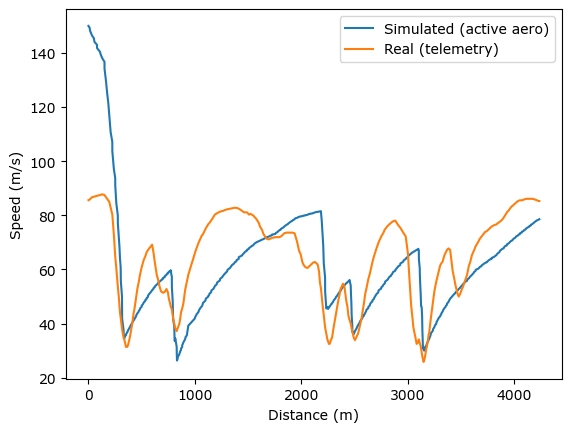

In [17]:
ds = np.gradient(telemetry['Distance'].values)

v_corner = np.array([max_corner_speed(r, aero_mode(r)) for r in radius])

v_fwd = np.zeros_like(v_corner)
v_fwd[0] = v_corner[0]
for i in range(1, len(v_fwd)):
    mode = aero_mode(radius[i])
    v_prev = v_fwd[i-1]
    F_drag = drag(v_prev, mode)
    F_trac_limit = mu * (m * g + downforce(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds[i], 0))
    v_fwd[i] = min(v_new, v_corner[i])

v_bwd = np.zeros_like(v_corner)
v_bwd[-1] = v_corner[-1]
for i in range(len(v_bwd)-2, -1, -1):
    v_next = v_bwd[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds[i+1], 0))
    v_bwd[i] = min(v_new, v_corner[i])

v_final = np.minimum(np.minimum(v_fwd, v_bwd), v_corner)
lap_time_sim = np.sum(ds[1:] / v_final[1:])

real_time_zandvoort = 71.163
gap = lap_time_sim - real_time_zandvoort
print(f"Simulated: {lap_time_sim:.2f} s, Gap: {gap:+.2f} s")

plt.plot(telemetry['Distance'], v_final, label='Simulated (active aero)')
plt.plot(telemetry['Distance'], telemetry['Speed']/3.6, label='Real (telemetry)')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.savefig('zandvoort_validation.png')
plt.show()


Fixed aero: 77.44 s, Saving: 2.34 s


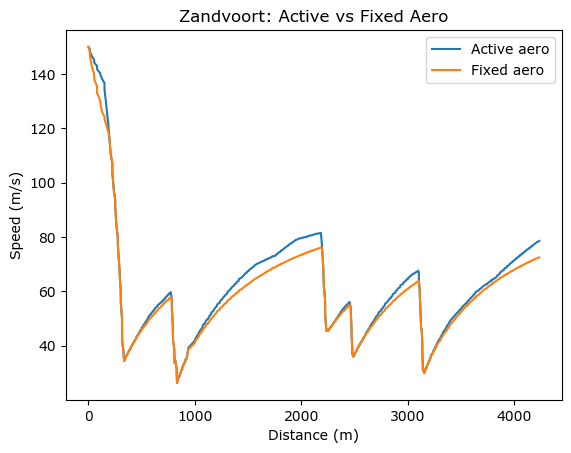

In [18]:
v_corner_fixed = np.array([max_corner_speed(r, aero_mode_fixed(r)) for r in radius])

v_fwd_fixed = np.zeros_like(v_corner_fixed)
v_fwd_fixed[0] = v_corner_fixed[0]
for i in range(1, len(v_fwd_fixed)):
    mode = aero_mode_fixed(radius[i])
    v_prev = v_fwd_fixed[i-1]
    F_drag = drag(v_prev, mode)
    F_trac_limit = mu * (m * g + downforce(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds[i], 0))
    v_fwd_fixed[i] = min(v_new, v_corner_fixed[i])

v_bwd_fixed = np.zeros_like(v_corner_fixed)
v_bwd_fixed[-1] = v_corner_fixed[-1]
for i in range(len(v_bwd_fixed)-2, -1, -1):
    v_next = v_bwd_fixed[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds[i+1], 0))
    v_bwd_fixed[i] = min(v_new, v_corner_fixed[i])

v_final_fixed = np.minimum(np.minimum(v_fwd_fixed, v_bwd_fixed), v_corner_fixed)
lap_time_fixed = np.sum(ds[1:] / v_final_fixed[1:])
print(f"Fixed aero: {lap_time_fixed:.2f} s, Saving: {lap_time_fixed - lap_time_sim:.2f} s")

plt.plot(telemetry['Distance'], v_final, label='Active aero')
plt.plot(telemetry['Distance'], v_final_fixed, label='Fixed aero')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.title('Zandvoort: Active vs Fixed Aero')
plt.savefig('zandvoort_active_vs_fixed.png')
plt.show()


In [19]:
x_m = telemetry_monza['X'].values
y_m = telemetry_monza['Y'].values
x_m_smooth = savgol_filter(x_m, window_length=21, polyorder=3)
y_m_smooth = savgol_filter(y_m, window_length=21, polyorder=3)
dx_m = np.gradient(x_m_smooth)
dy_m = np.gradient(y_m_smooth)
ddx_m = np.gradient(dx_m)
ddy_m = np.gradient(dy_m)
curvature_m = np.abs(dx_m * ddy_m - dy_m * ddx_m) / (dx_m**2 + dy_m**2)**1.5
radius_m = 1 / np.maximum(curvature_m, 1e-6)
radius_m_clipped = np.clip(radius_m, 40, None)


In [20]:
mu_monza = 0.5
Cl_Z_monza, Cd_Z_monza = 1.8, 1.65
Cl_X_monza, Cd_X_monza = 1.1, 0.95

def downforce_monza(v, mode):
    Cl = Cl_X_monza if mode == 'X' else Cl_Z_monza
    return 0.5 * rho * Cl * A * v**2

def drag_monza(v, mode):
    Cd = Cd_X_monza if mode == 'X' else Cd_Z_monza
    return 0.5 * rho * Cd * A * v**2

def max_corner_speed_monza(radius_i, mode):
    def equation(v):
        F_down = downforce_monza(v, mode)
        return mu_monza * (m * g + F_down) / m - v**2 / radius_i
    if equation(150) > 0:
        return 150.0
    return brentq(equation, 1, 150)


Simulated: 85.08 s, Gap: +3.30 s


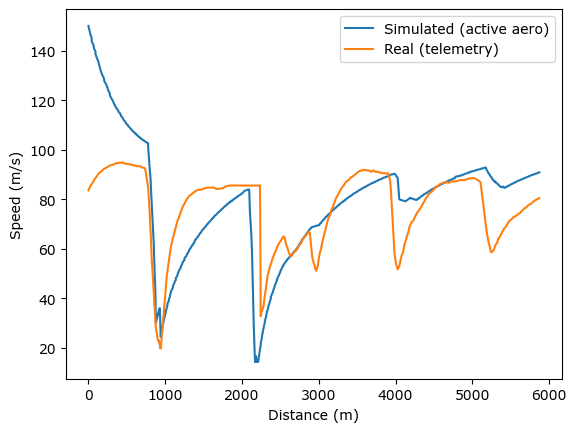

In [21]:
ds_m = np.gradient(telemetry_monza['Distance'].values)

v_corner_m = np.array([max_corner_speed_monza(r, aero_mode(r)) for r in radius_m_clipped])

v_fwd_m = np.zeros_like(v_corner_m)
v_fwd_m[0] = v_corner_m[0]
for i in range(1, len(v_fwd_m)):
    mode = aero_mode(radius_m_clipped[i])
    v_prev = v_fwd_m[i-1]
    F_drag = drag_monza(v_prev, mode)
    F_trac_limit = mu_monza * (m * g + downforce_monza(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds_m[i], 0))
    v_fwd_m[i] = min(v_new, v_corner_m[i])

v_bwd_m = np.zeros_like(v_corner_m)
v_bwd_m[-1] = v_corner_m[-1]
for i in range(len(v_bwd_m)-2, -1, -1):
    v_next = v_bwd_m[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds_m[i+1], 0))
    v_bwd_m[i] = min(v_new, v_corner_m[i])

v_final_m = np.minimum(np.minimum(v_fwd_m, v_bwd_m), v_corner_m)
lap_time_sim_m = np.sum(ds_m[1:] / v_final_m[1:])

real_time_monza = 81.786
gap_monza = lap_time_sim_m - real_time_monza
print(f"Simulated: {lap_time_sim_m:.2f} s, Gap: {gap_monza:+.2f} s")

plt.plot(telemetry_monza['Distance'], v_final_m, label='Simulated (active aero)')
plt.plot(telemetry_monza['Distance'], telemetry_monza['Speed']/3.6, label='Real (telemetry)')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.savefig('monza_validation.png')
plt.show()


Fixed aero: 95.02 s, Saving: 9.93 s


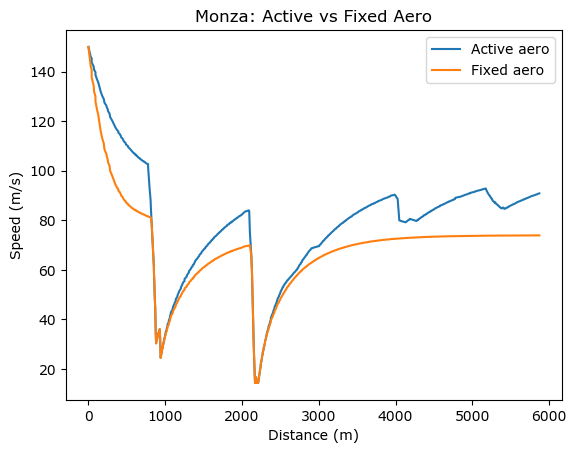

In [22]:
v_corner_fixed_m = np.array([max_corner_speed_monza(r, aero_mode_fixed(r)) for r in radius_m_clipped])

v_fwd_fixed_m = np.zeros_like(v_corner_fixed_m)
v_fwd_fixed_m[0] = v_corner_fixed_m[0]
for i in range(1, len(v_fwd_fixed_m)):
    mode = aero_mode_fixed(radius_m_clipped[i])
    v_prev = v_fwd_fixed_m[i-1]
    F_drag = drag_monza(v_prev, mode)
    F_trac_limit = mu_monza * (m * g + downforce_monza(v_prev, mode))
    F_power_limit = P_max / max(v_prev, 1)
    F_traction = min(F_trac_limit, F_power_limit)
    a = (F_traction - F_drag) / m
    v_new = np.sqrt(max(v_prev**2 + 2*a*ds_m[i], 0))
    v_fwd_fixed_m[i] = min(v_new, v_corner_fixed_m[i])

v_bwd_fixed_m = np.zeros_like(v_corner_fixed_m)
v_bwd_fixed_m[-1] = v_corner_fixed_m[-1]
for i in range(len(v_bwd_fixed_m)-2, -1, -1):
    v_next = v_bwd_fixed_m[i+1]
    v_new = np.sqrt(max(v_next**2 + 2*a_brake_max*ds_m[i+1], 0))
    v_bwd_fixed_m[i] = min(v_new, v_corner_fixed_m[i])

v_final_fixed_m = np.minimum(np.minimum(v_fwd_fixed_m, v_bwd_fixed_m), v_corner_fixed_m)
lap_time_fixed_m = np.sum(ds_m[1:] / v_final_fixed_m[1:])
print(f"Fixed aero: {lap_time_fixed_m:.2f} s, Saving: {lap_time_fixed_m - lap_time_sim_m:.2f} s")

plt.plot(telemetry_monza['Distance'], v_final_m, label='Active aero')
plt.plot(telemetry_monza['Distance'], v_final_fixed_m, label='Fixed aero')
plt.legend()
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.title('Monza: Active vs Fixed Aero')
plt.savefig('monza_active_vs_fixed.png')
plt.show()
